# Visualization Module - Lecture 5 Scripts and Notes

## Coding session

In [40]:
# What is seaborn: It is a data viz package built on top of matplotlib.

# Setup to load all required packages
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [41]:
# Load dataset for visualization
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


[Text(0.5, 1.0, 'Tips vs. Total Bills'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

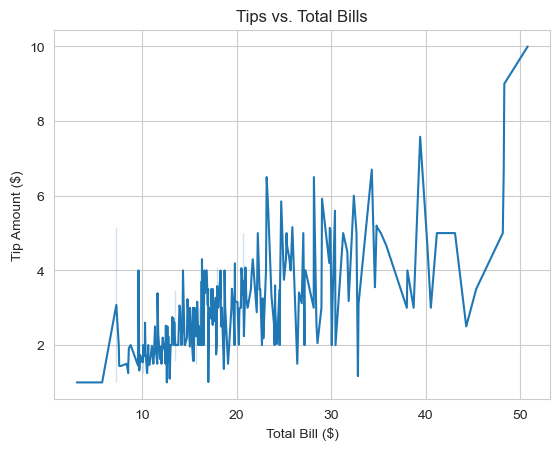

In [42]:
# Simple plot showing tips vs. bill amounts in a restaurant
tipgraph = sns.lineplot(data=tips, # choose our dataset 
             x='total_bill', # define our x variable 
             y='tip') # define our y variable
tipgraph.set(title = "Tips vs. Total Bills",
             xlabel = "Total Bill ($)",
             ylabel = "Tip Amount ($)")

[Text(0.5, 1.0, 'Tips vs. Total Bills'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

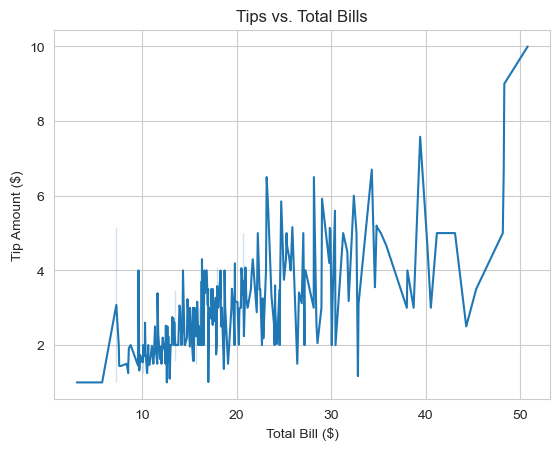

In [43]:
# Add white grid to plot
sns.set_style('whitegrid')
#sns.set_style('dark')
tipgraph = sns.lineplot(data=tips, # choose our dataset 
             x='total_bill', # define our x variable 
             y='tip') # define our y variable
tipgraph.set(title = "Tips vs. Total Bills",
             xlabel = "Total Bill ($)",
             ylabel = "Tip Amount ($)")

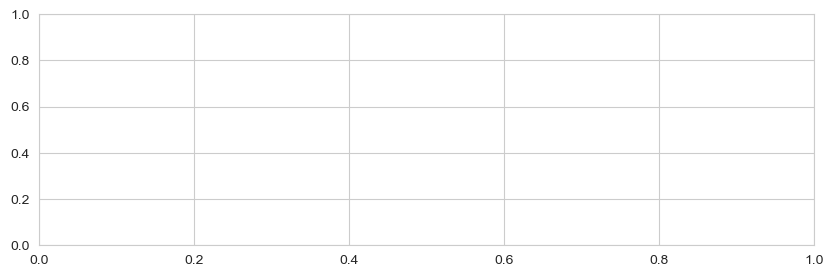

In [44]:
# Create canvas for figure
fig = plt.subplots(figsize=(10, 3))

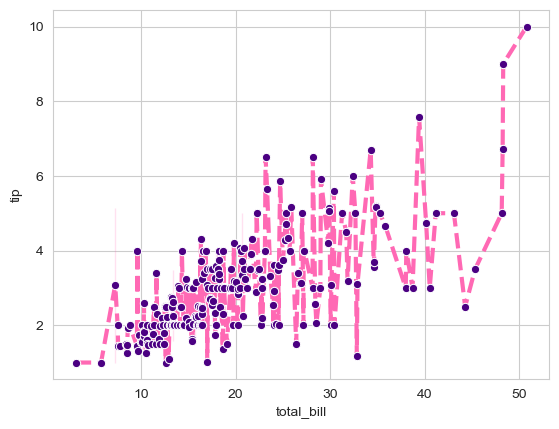

In [45]:
# Change color, marker style, and line style

tipgraph = sns.lineplot(data=tips, 
                        x='total_bill', 
                        y='tip', 
                        color = 'hotpink', 
                        linestyle = '--', 
                        linewidth = 3, 
                        marker = 'o', 
                        markerfacecolor = 'indigo')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

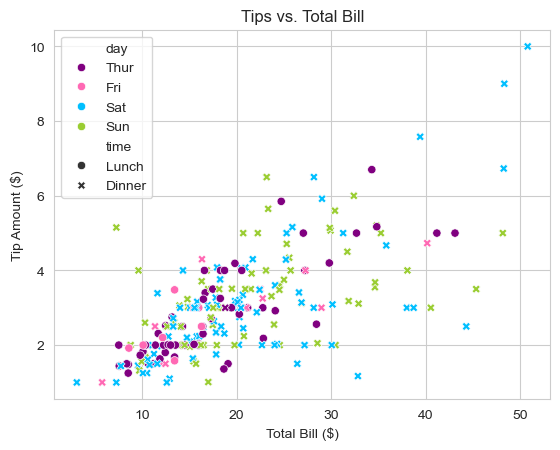

In [46]:
# Use seaborn to represent variables with different visual elements in the plot

tipgraph = sns.scatterplot(data=tips, 
                           x='total_bill', 
                           y='tip', 
                           style = 'time', 
                           hue = 'day', 
                           palette = ['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])

tipgraph.set(title='Tips vs. Total Bill', 
             xlabel='Total Bill ($)', 
             ylabel='Tip Amount ($)')

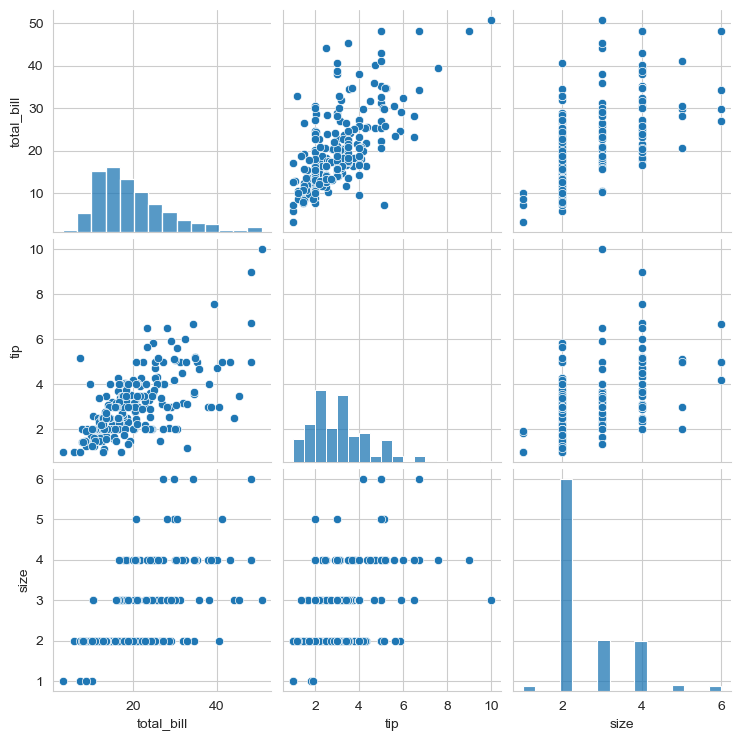

In [47]:
# Pairplot: A pairplot is a convenient way to compare variables
sns.pairplot(data = tips) 


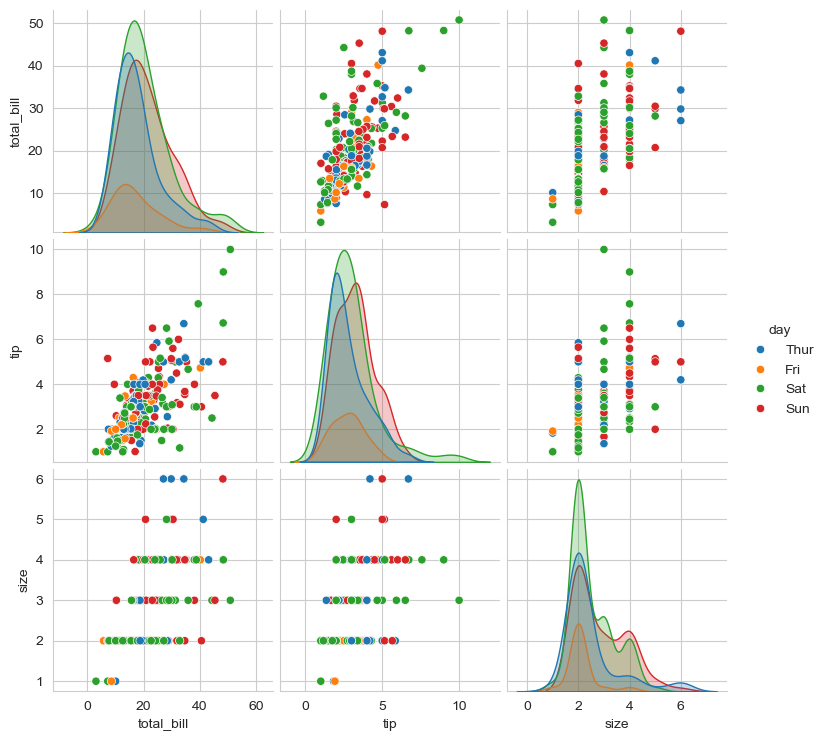

In [48]:
# Change hue by weekday
sns.pairplot(data = tips ,hue = 'day')

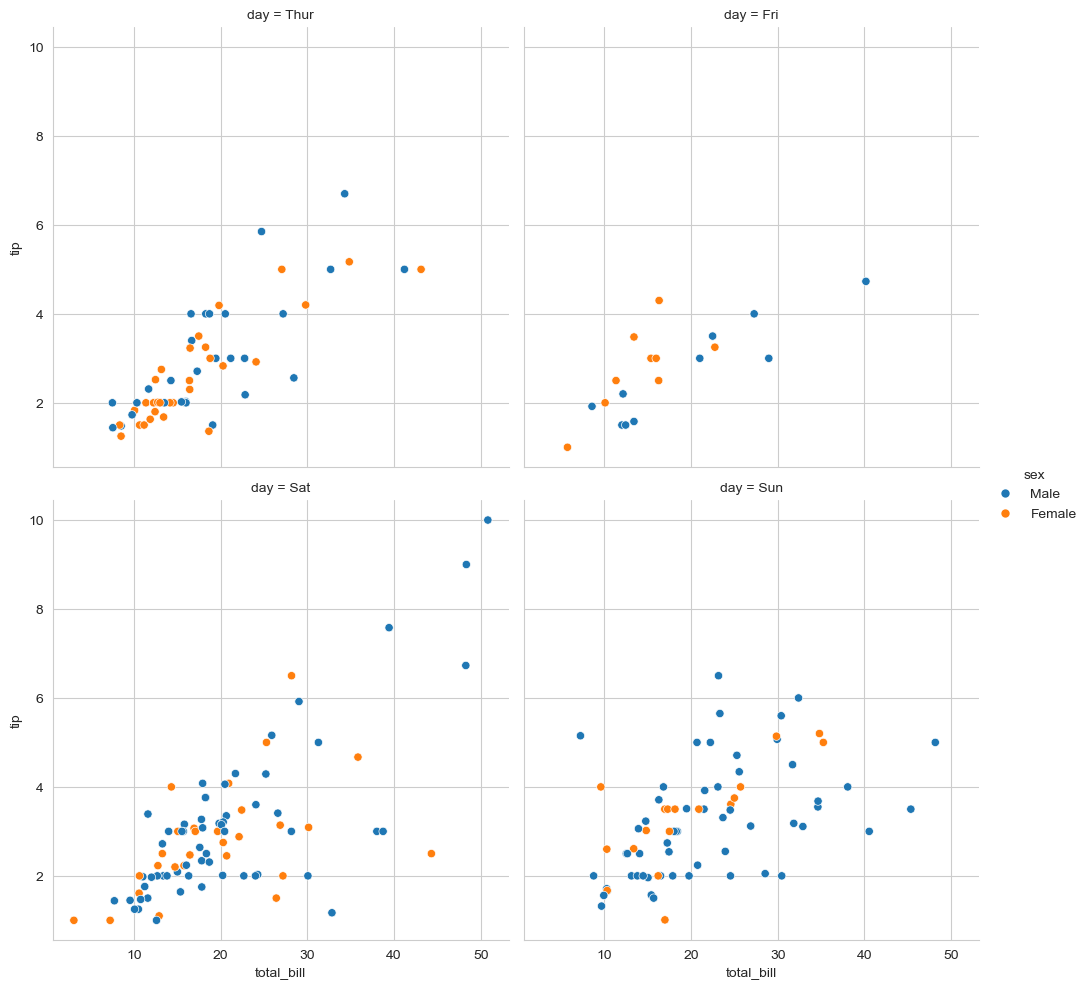

In [49]:
# Replot
# Use replot to visulize the relationship between tipping in a restaurant by gender
# Each weekday is shown in a dedicated subplot

daysplot = sns.relplot(data=tips, 
                       x="total_bill", 
                       y="tip", hue="sex", 
                       col="day", 
                       kind="scatter", 
                       col_wrap=2)


## Activities

### Comparing data visualizations

The left visualization is much simpler and requires less cognitive load to view and understanding. The right interative visualization is more engaging but the results displayed are not exact, viewer would apply their own interpretation on the visualization and could sometimes be subjective.

### Types of changes

1. What types of changes occur when weinteract with this dynamic datavisualization?- The types of changes that occur when we interact with the dynamic data visualization include showing all ratings, only positive or only negative ratings.

2. Which spatial and retinal elements stay constant? Which change?
- The legend color for male and female remain unchanged. The categories on the y-axis that refer to the disciplines change their order based on the ranking when a subset of the types of ratings is selected. 

3. If I am to redesign the viz, one enhancement I would add is to also let the users to choose ranking from ascending vs. descending. As currently, how the data is ordered dynamically is not explictly shown to be ascending vs. descending, it is implicit. 


## Plotly coding session

In [50]:
# Setup plotly 

import plotly.graph_objects as go

In [51]:
# Create dataset
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [52]:
# Make a figure
graph = go.Figure()

In [53]:
# Create a bar chart
graph.add_trace(go.Bar(x=x1, y=y1))

In [54]:
# Add main title and labels for x- and y-axis
graph.update_layout( title="Pirate Scores", 
                    xaxis_title="Pirates", 
                    yaxis_title="Score")

In [55]:
# Customize plotly and create an interactive plot

graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, 
                           y=y1, 
                           mode='markers', # we want points for a scatter plot 
                           marker=dict(
                               size=15, # point size 
                               color='hotpink', # point colour 
                               opacity=1, # point transparency/alpha 
                               line=dict(width=5, color='purple') # point outline 
                               )))

graph.update_layout(title='Interactive Pirate Plot', 
                    xaxis_title='Pirates', 
                    yaxis_title='Scores', 
                    width=500, 
                    height=500)

### Wordcloud creation using Plotly

In [56]:
# Set up word cloud package
! pip install wordcloud

from wordcloud import WordCloud

In [57]:
from wordcloud import WordCloud

In [58]:
# Load dataset into a dataframe for creating word cloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv", 
                 on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


### Make wordcloud

(-0.5, 399.5, 199.5, -0.5)

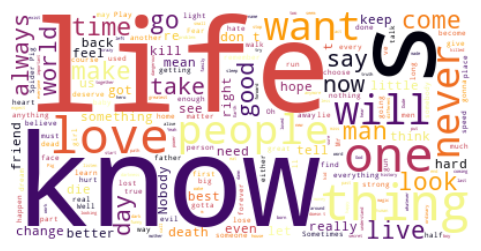

In [59]:
# join all our text from each row from our quote column into a string
text = " ".join(each for each in df.quote)

# generate our wordcloud image
wordcloud = WordCloud(background_color="white",colormap = 'inferno').generate(text)

# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, # remember 'imshow' from when we added pictures to our matplotlib axes 
          interpolation='bilinear') # this line helps smooth our image
ax.axis("off")

### Make venn diagram with Plotly

In [60]:
! pip install matplotlib_venn

In [61]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [62]:
# define dataset
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

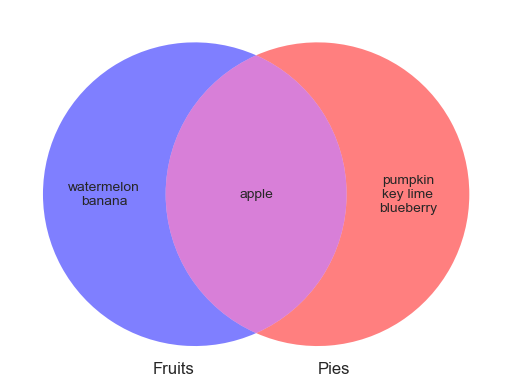

In [66]:
# Create venn diagram

diagram = venn2_unweighted([A, B], 
                           set_labels = ('Fruits', 'Pies'), 
                           set_colors=("blue", "red"), 
                           alpha=0.5)

# Modify venn diagram
diagram.get_label_by_id("10").set_text("\n".join(A - B))
diagram.get_label_by_id("11").set_text("\n".join(A & B))
diagram.get_label_by_id("01").set_text("\n".join(B - A))
